<a href="https://colab.research.google.com/github/juliovaldeze-gif/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print('Se obtiene la cantidad de nulos por columna para dataset Users')
print(users.isna().sum())
print()
print('Se obtiene la proporcion')
print(users.isna().mean())

Se obtiene la cantidad de nulos por columna para dataset Users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Se obtiene la proporcion
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print('Se obtiene la cantidad de nulos por columna')
print(usage.isna().sum())
print()
print('Se obtiene la proporcion')
print(usage.isna().mean())

Se obtiene la cantidad de nulos por columna
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Se obtiene la proporcion
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**

🔍 Para el dataframe de Users
-  💡 Se observa que para el DataSet de Users Tenemos 469 registros con la ciudad en nulo que representan el 11% de los registros y 3534 con el churndate en nulo que representa el 88% de los registros. Ademas de observar que en el archivo origen los valores del campo churndate tienen un formato invalido de fecha
-  💡 Para el campo city se imputara
-  💡 Para el campo churndate se eliminara esta columna


🔍 Para el datafrane de usage
-  💡 Se observa que para el DataSet de Usage Tenemos 50 registros con el date en nulo que repesentan el 0.125% y duration tiene 22,076 en nulo y es el 55% y el length tiene 17,896 que representan el 44%
-  💡 Para el campo date se imputaran los valores nulos
-  💡 Para los campos duration y length se imputaran con Nan o una fecha o duracion promedio

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
# Resumen estadístico de user_id del dataframe users
print(users['user_id'].describe())
print()
print(users['user_id'].unique())


count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64

[10000 10001 10002 ... 13997 13998 13999]


In [ ]:
# Resumen estadístico de age del dataframe users
print(users['age'].describe())
print()
print(users['age'].unique())

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

[  38   53   57   69   63   61   39   70   76   47   67   60 -999   78
   77   25   51   74   64   26   68   37   42   36   22   28   32   40
   44   49   43   79   59   46   56   58   50   54   33   24   29   45
   66   30   35   65   18   55   19   23   41   27   34   72   75   31
   71   52   20   73   21   62   48]


- 💡 La columna user_id contiene identificadores únicos de usuarios. Se registran 4,000 usuarios .Los identificadores parecen asignarse de forma secuencial y uniforme, ya que la la mediana no esta tan alejada de la media. La columna se ve OK por lo que no requiere limpieza
- 💡 La columna age tiene una edad promedio de los usuarios es de 33.7 años. El 50% de los usuarios tiene 47 años o menos, y la mayoría de las edades se encuentra entre 32 y 63 años. Y podemos obervar un valor mínimo de -999, lo que indica un dato inválido o un valor sentinel, por lo que la columna requiere que para estos valores los corregiremos usando una edad promedio

In [ ]:
# explorar columnas numéricas de usage
# Resumen estadístico de age del dataframe usage
print(usage['id'].describe())
print()
print(usage['id'].unique())

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64

[    1     2     3 ... 39998 39999 40000]


In [ ]:
# Resumen estadístico de age del dataframe usage
print(usage['user_id'].describe())
print()
print(usage['user_id'].unique())

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64

[10332 11458 11777 ... 10278 12723 13883]


- 💡 La columna id contiene 40,000 registros con valores que van de 1 a 40,000. La media y la mediana se ubican cerca del centro del rango, lo que sugiere que los identificadores están distribuidos de manera uniforme y secuencial. Esta columna se ve OK y no requiere limpieza

- 💡 La columna user_id contiene 40,000 registros asociados a usuarios cuyos identificadores van de 10,000 a 13,999. La media (12,002.4) y la mediana (12,013) se encuentran cerca del centro del rango, lo que indica una distribución equilibrada de los registros entre los usuarios. La columna se ve OK y no requiere limpieza

In [ ]:
# explorar columnas categóricas de users
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print("\nDescribe: ", col)
    print(users[col].describe())
    print("\nValores únicos de:", col)
    print(users[col].unique())
    print("\nValores nulos de:", col)
    print(users[col].isna().sum())




Describe:  city
count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

Valores únicos de: city
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores nulos de: city
469

Describe:  plan
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object

Valores únicos de: plan
['Basico' 'Premium']

Valores nulos de: plan
0



- 💡 La columna City tiene 7 ciudades "válidas", pero aparecen 8 valores únicos debido a la presencia de NaN y '?', que son valores inválidos y deben corregirse. Cabe mencionar que existen 469 registros en nulo que deben ser imputados. Tambien es conveniente estandarizar los nombres de las ciudades siguiendo el patron de Acronimos como CDMX, GDL, MTY
- La columna `plan` tiene solo dos valores. No tiene valores nulos. La columna esta OK no requiere limpieza

In [ ]:
# explorar columna categórica de usage
# explorar columna categórica de usage llamada type
print(usage['type'].describe())
print()
print(usage['type'].unique())
print()
print("Valores nulos: ",usage['type'].isna().sum())


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

['call' 'text']

Valores nulos:  0


- 💡 La columna type tiene solo dos valores: "call" y "text". No tiene valores nulos. La columna se ve Ok no requiere limpieza

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- Las columnas que se detectaron con valores invalidos o sentinels fueron :
  
**Del dataframe USERS**

   - Age -> Contienen un valor sentinel de -999 el cual se recomienda imputarlo con NaN
   - city -> contiene 469 valores en nulo por lo que se debe de reemplazar por NaN
   - churn_date -> contiene 3,534 registros en nulo que debido al nombre del campo lo mas
                   probable es que sean clientes que aun no cancelan su plan. Lo
                   que hay que revisar son los valores no nulos que contienen datos con un
                   formato de fecha invalido. Estos datos se deben de corregir

**NOTA.- el archivo "users_latam.csv" lo baje 2 veces y al abrirlo con un bloque de notas
  antes de abrirlo con un excel , los valores no nulos de churn_date ya venian con formato
  invalido. No se si es un error y el archivo se subio al servidor de tripleten con un
  formato que no es fecha, pero para este proyecto yo lo voy a tomar como un error
  deliberado que hay que decidir como corregirlo.**
     
**Del dataframe USAGE**

  - date -> tiene 50 registros en nulo por lo que hay que imputar estos registros
  - duration -> tiene 17,924 registros nulos por lo que hay que imputar estos registros
  - length -> tiene 22,104 registros nulos por lo que hay que imputar estos registros

**Del dataframe PLANS**

    Como solo tiene 2 registros y todo se ve OK. Para este dataframe no se requiere limpieza
    


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  

**hallazgos**

💡 se observa que en el campo reg_date hay fechas del 2026 cuando para el proyecto solo se tienen registradas fechas hasta el 2024. Probablemente es un error de captura que hay que corregir reemplazando el año por 2024

💡 se observa que el campo date tiene un '.' al final del año que hay que corregir, y los valores 'nan' deben de imputarse.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print((users['city'] == '?').sum())

0


In [ ]:
#Fechas con año 2026 antes del reemplazo
print("\nFechas 2026 antes del reemplazo")
print((users['reg_date'].dt.year == 2026).sum())

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
print("\nFechas 2026 despues del reemplazo")
print((users['reg_date'].dt.year == 2026).sum())
print("\nFechas nulas despues del reemplazo")
print(users['reg_date'].isna().sum())


Fechas 2026 antes del reemplazo
40

Fechas 2026 despues del reemplazo
0

Fechas nulas despues del reemplazo
40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().sum()

pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    normalize='index'
)


duration,False,True
type,,
call,1.000000,0.000000
text,0.000724,0.999276


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().sum()

pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    normalize='index'
)


length,False,True
type,,
call,0.00067,0.99933
text,1.00000,0.00000


💡 Podemos concluir que los nulos de duration y length pueden clasificarse como MAR (Missing At Random) porque su ausencia depende de una variable observada: type.

Más específicamente:

duration está vacío cuando type = 'text'.
length está vacío cuando type = 'call'.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`
- `cant_llamadas`
- `cant_minutos_llamada`
-
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)

user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.122250
std,1154.844867,17.690408
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:

- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`


Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

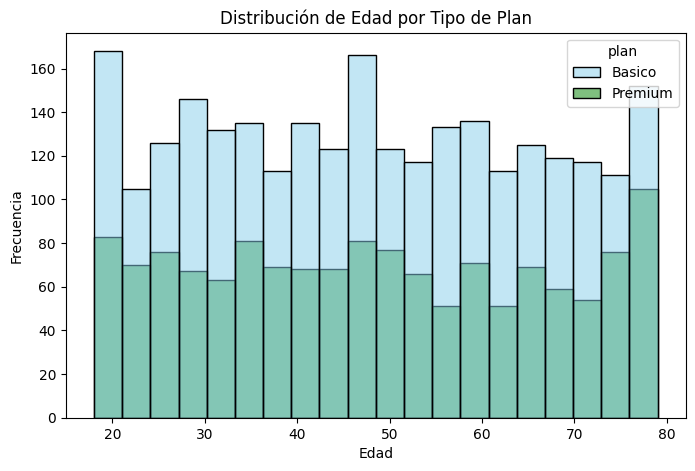

In [ ]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()



💡 **Insight:**

La distribución de edades es bastante uniforme entre los 18 y 79 años para ambos planes, sin concentraciones marcadas en un rango de edad específico.
Además, el plan Básico cuenta con más usuarios que el plan Premium en casi todos los grupos de edad.



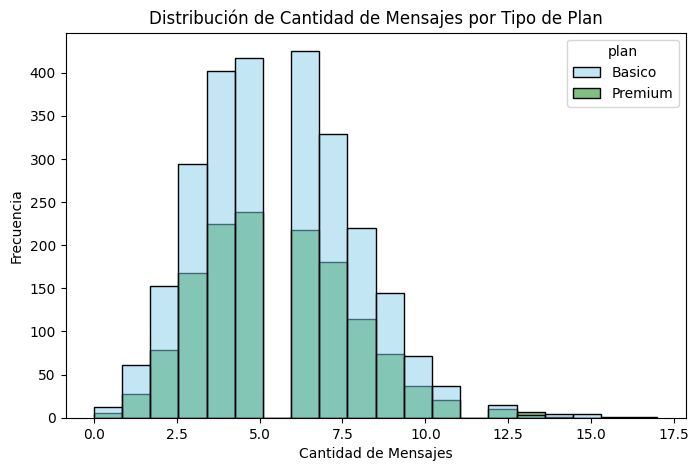

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡 **Insight:**

La mayoría de los usuarios envía entre 3 y 8 mensajes, siendo los valores más frecuentes alrededor de 4 a 7 mensajes.
Las distribuciones de los planes Básico y Premium son muy similares, aunque el plan Básico concentra una mayor cantidad de usuarios.

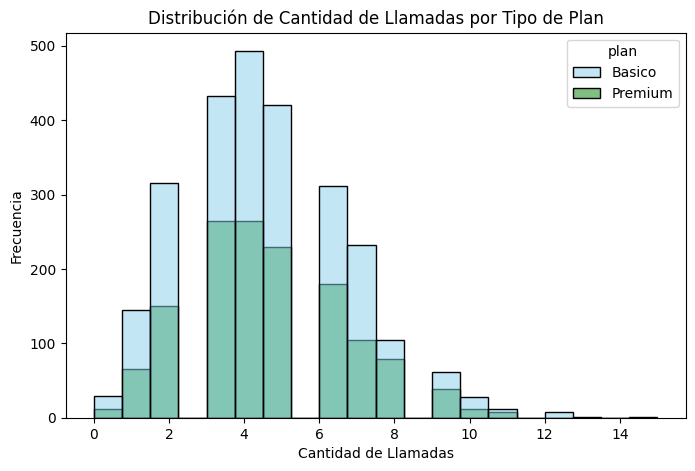

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')

plt.show()

💡 **Insight:**

La mayoría de los usuarios de ambos planes realizan entre 3 y 7 llamadas, concentrándose especialmente alrededor de 4 a 5 llamadas, lo que indica un patrón de uso muy similar entre los planes Básico y Premium.

Además, existen pocos usuarios con una cantidad muy alta de llamadas (más de 10), por lo que la distribución presenta una cola hacia la derecha debido a estos casos excepcionales.

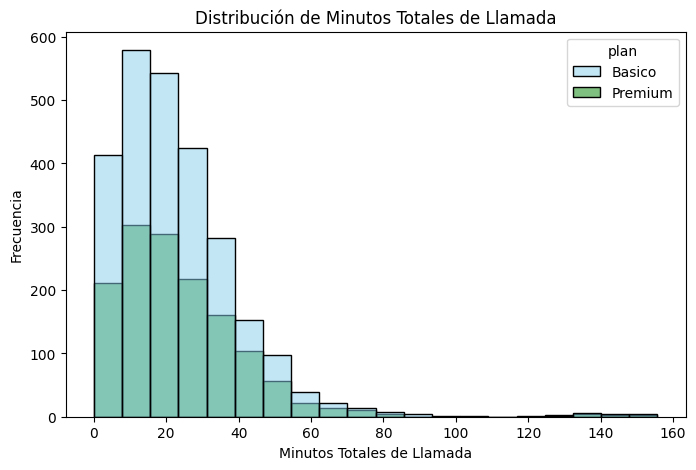

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,5))

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Distribución de Minutos Totales de Llamada')
plt.xlabel('Minutos Totales de Llamada')
plt.ylabel('Frecuencia')

plt.show()


💡 **Insight:**

La mayor parte de los usuarios acumula entre 5 y 35 minutos de llamadas, concentrándose especialmente alrededor de los 10 a 25 minutos, lo que indica un uso moderado del servicio en ambos planes.

Además, la distribución está sesgada hacia la derecha, ya que existen pocos usuarios con consumos muy altos (más de 60 minutos), considerados casos poco frecuentes en comparación con la mayoría.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  

- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


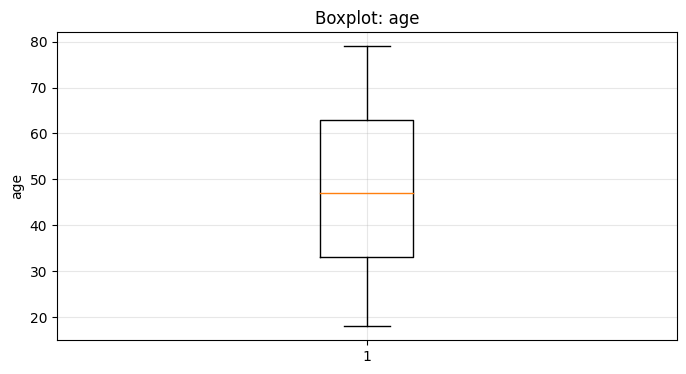

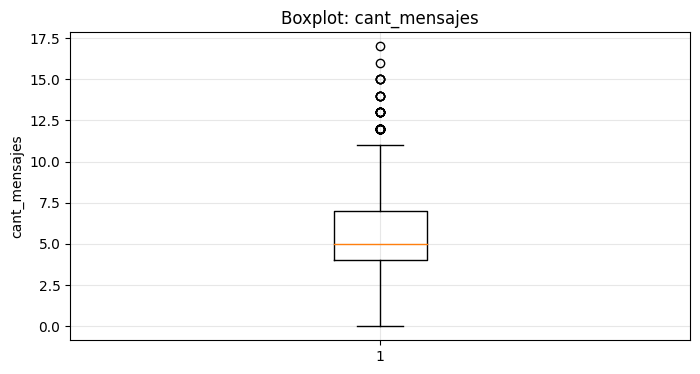

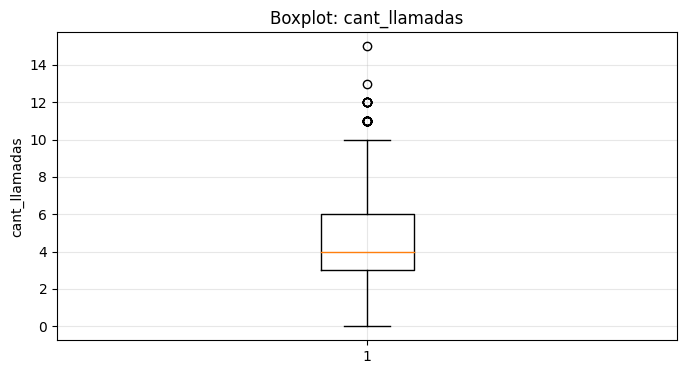

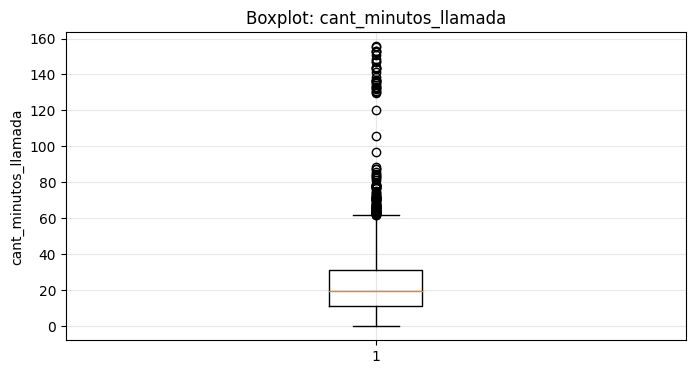

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,4))
    plt.boxplot(user_profile[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()

💡Insights:
- Age: No presenta outliers, Todas las edades parecen estar dentro de un rango normal para la muestra analizada.

- cant_mensajes: sí tiene outliers, y estos se encuentran únicamente en el extremo superior de la distribución (outliers altos). Esto sugiere la presencia de algunos usuarios mucho más activos en el envío de mensajes que el resto de la muestra.

- cant_llamadas: sí contiene outliers, y estos se encuentran únicamente en la parte superior de la distribución. Esto sugiere la existencia de un pequeño grupo de usuarios con un uso de llamadas mucho más intensivo que el comportamiento típico de la muestra.

- cant_minutos_llamada: si presenta outliers altos de forma significativa. Sin embargo, estos valores probablemente representan usuarios con un uso intensivo del servicio y no necesariamente errores en los datos, no se recomienda eliminarlos, ya que forman parte del comportamiento real de los clientes y podrían ser importantes para el análisis del uso de los planes.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = user_profile[
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)
    ]

    print(f'\n{col}')
    print(f'Limite inferior: {limite_inferior:.2f}')
    print(f'Limite superior: {limite_superior:.2f}')
    print(f'Cantidad de outliers: {len(outliers)}')



age
Limite inferior: -12.00
Limite superior: 108.00
Cantidad de outliers: 0

cant_mensajes
Limite inferior: -0.50
Limite superior: 11.50
Cantidad de outliers: 46

cant_llamadas
Limite inferior: -1.50
Limite superior: 10.50
Cantidad de outliers: 30

cant_minutos_llamada
Limite inferior: -19.32
Limite superior: 61.86
Cantidad de outliers: 109


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:

cant_mensajes: ¿Mantener o no los outliers?

✅ Mantenerlos.

Los valores máximos llegan a 17 mensajes, mientras que el 75% de los usuarios envía 7 mensajes o menos. Aunque existen usuarios más activos, estos valores son plausibles y representan comportamientos reales de uso, no errores de captura.

cant_llamadas: ¿Mantener o no los outliers?

✅ Mantenerlos.

El máximo es de 15 llamadas, frente a una mediana de 4 llamadas. Los usuarios con muchas llamadas son una minoría, pero siguen reflejando patrones legítimos de consumo del servicio. Eliminarlos podría sesgar el análisis del comportamiento de los clientes más activos.

cant_minutos_llamada: ¿Mantener o no los outliers?

✅ Mantenerlos, pero analizarlos con atención.

Aunque existen valores muy altos (hasta 155.69 minutos) comparados con una mediana de 19.78 minutos, estos registros pueden corresponder a usuarios con un uso intensivo del servicio. No hay evidencia de errores o valores imposibles, por lo que es preferible conservarlos para no perder información relevante sobre los clientes de mayor consumo.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = [
    'Bajo uso',
    'Uso medio'
]

user_profile['grupo_uso'] = np.select(
    condiciones,
    valores,
    default='Alto uso'
)



In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
condiciones = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

valores = [
    'Joven',
    'Adulto'
]

user_profile['grupo_edad'] = np.select(
    condiciones,
    valores,
    default='Adulto Mayor'
)



In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

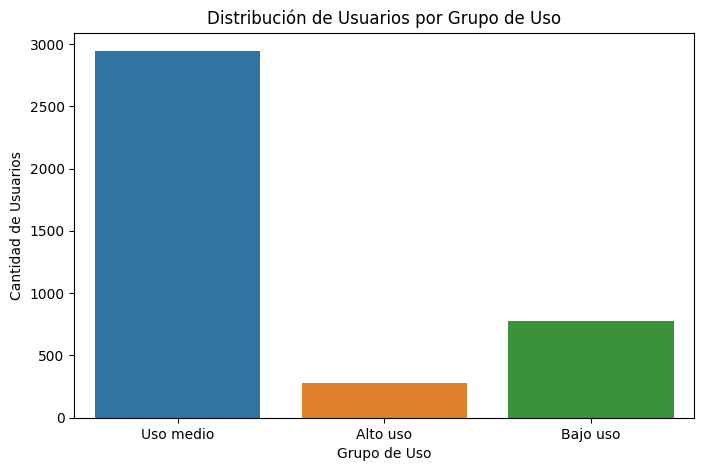

In [ ]:
# Visualización de los segmentos por uso

# Gráfico para grupo_uso
plt.figure(figsize=(8,5))
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


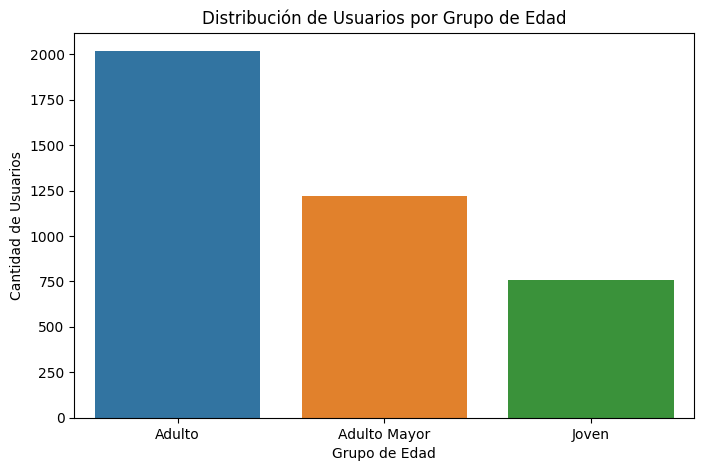

In [ ]:
# Visualización de los segmentos por edad

# Gráfico para grupo_edad
plt.figure(figsize=(8,5))
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

🚨 **Se encontraron algunos valores ausentes en variables de uso (1 registro por columna, menos del 1% del total) y outliers en mensajes, llamadas y minutos de llamada.**
  
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

🚨 **Se identificaron segmentos por edad (Joven, Adulto y Adulto Mayor) y por uso (Bajo, Medio y Alto); los adultos concentran la mayor parte de la actividad y los usuarios de alto uso generan más consumo.**

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

🚨 **Los usuarios de Alto Uso son los más valiosos porque consumen más servicios y tienen mayor potencial de generar ingresos mediante planes premium.**

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

🚨 **Se encontraron outliers en mensajes, llamadas y minutos, lo que indica la existencia de clientes con consumo intensivo que pueden requerir ofertas especializadas**

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

🚨 **Crear planes premium para usuarios intensivos, ofertas específicas por grupo de edad y estrategias de upselling para clientes de uso medio.**


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Se identificaron algunos valores ausentes en las variables de uso (cant_mensajes, cant_llamadas y cant_minutos_llamada), representando una proporción mínima del total de registros (<1%).
- Se detectaron outliers en las variables de mensajes, llamadas y minutos de llamada. Sin embargo, estos valores corresponden a usuarios con un consumo elevado y no parecen ser errores de captura.
- La variable age no presentó valores atípicos ni inconsistencias relevantes.

🔍 **Segmentos por Edad**

- Jóvenes (<30 años): representan el grupo más pequeño y muestran patrones de uso moderados.
- Adultos (30-59 años): constituyen la mayoría de los clientes y concentran gran parte de la actividad de llamadas y mensajes.
- Adultos Mayores (60+ años): presentan un uso más orientado a llamadas tradicionales y menor actividad general.


📊 **Segmentos por Nivel de Uso**

- Bajo Uso: usuarios con pocas llamadas y mensajes; representan clientes con baja interacción con los servicios.
- Uso Medio: es el segmento predominante y refleja el comportamiento típico de la mayoría de los clientes.
- Alto Uso: grupo reducido de usuarios que generan una cantidad significativamente mayor de llamadas, mensajes y minutos consumidos.

➡️ Esto sugiere que ...

- La mayor parte de los ingresos potenciales proviene de los usuarios de Uso Medio y Alto Uso.
- Existen necesidades diferentes según la edad y el nivel de consumo, por lo que una estrategia de planes únicos puede no ser la más eficiente.
- Los usuarios de alto consumo representan una oportunidad para productos premium y programas de fidelización.


💡 **Recomendaciones**

- Crear un Plan Premium dirigido a clientes de Alto Uso con mayores beneficios en llamadas y mensajería.
- Diseñar ofertas diferenciadas para jóvenes y adultos mayores, considerando sus patrones de consumo específicos.
- Implementar campañas de upselling para migrar usuarios de Uso Medio hacia planes de mayor valor.
- Mantener el monitoreo de usuarios con consumo extremo para identificar oportunidades comerciales y mejorar la retención de clientes.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`